In [1]:
library(Seurat)
library(scop)
library(Signac)
library(ggplot2)
set.seed(4180)
library(patchwork)
setwd("/")
#########color
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp




Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'scop':
  method             from  
  FoldChange.default Seurat

          ⬢          .        ⬡             ⬢     .
                     _____ _________  ____
                    / ___// ___/ __ ./ __ .
                   (__  )/ /__/ /_/ / /_/ /
                  /____/ .___/.____/ .___/
                                  /_/
      ⬢               .      ⬡        .          ⬢

------------------------------------------------------------
Version: 0.8.7 (2026-03-31 update)
Website: https://mengxu98.github.io/scop/

Python environment initialization is disabled
To enable it, set: options(scop_env_init = TRUE)

The message can be suppressed by: 
  suppressPackageStartupMessages(library(scop))
  or options(log_message.verbose = FALSE)
------------------------------------------------------------



In [2]:
mHeart <- readRDS("data/mHeart.Rds")

In [3]:
mHeart_ATAC <- readRDS("data/mHeart_ATAC.Rds")
mHeart[['ATAC']] <- mHeart_ATAC[['ATAC']]

In [4]:
mHeart[['activity']] <- readRDS("data/activity.Rds")[['activity']]
mHeart[['motif']] <- readRDS("data/motif.Rds")[['motif']]

In [3]:
table(mHeart$celltype)


       vCM        aCM         FB         EC     EndoCC        LEC        SMC 
     37984       2967      21551       7396       2300        226        159 
  Pericyte  Adipocyte   Neuronal          T          B Macrophage         DC 
      6548        275       1613        274        482       6491        151 

In [5]:
mHeart

An object of class Seurat 
241442 features across 91425 samples within 4 assays 
Active assay: RNA (26111 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 other assays present: ATAC, activity, motif
 7 dimensional reductions calculated: pca, harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

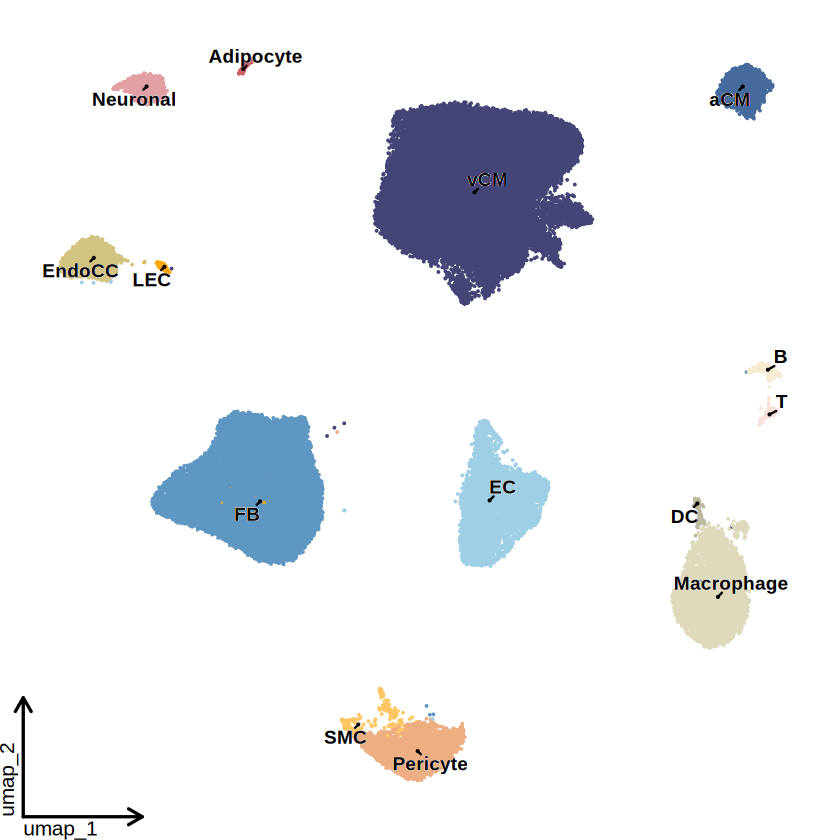

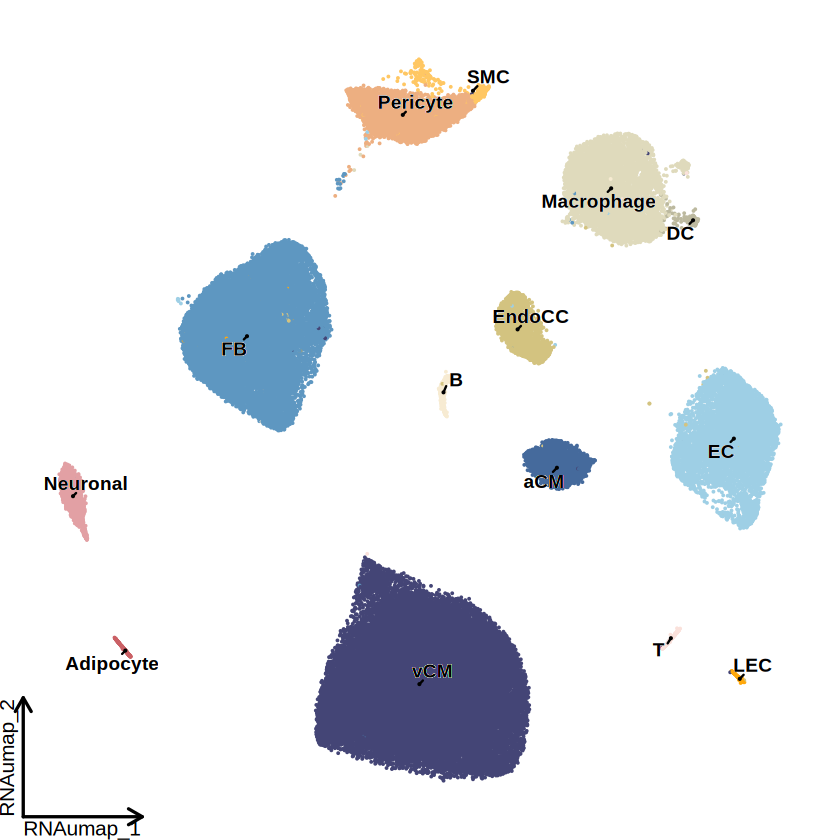

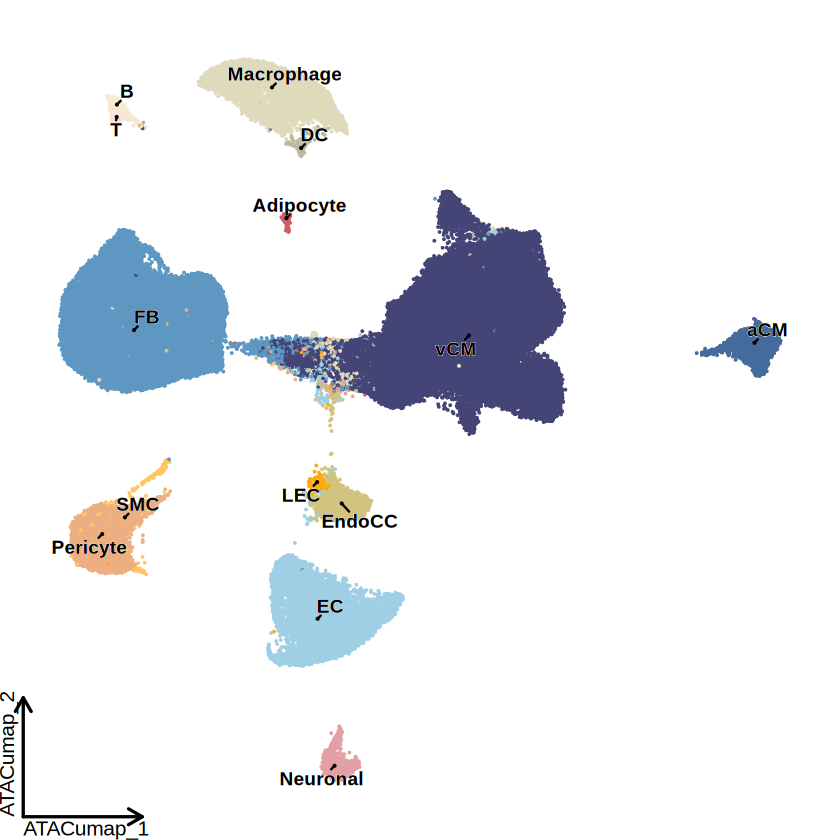

In [6]:
#fig1b celltype umap
p1<-CellDimPlot(
 srt = mHeart,group.by = 'celltype',legend.position = 'none',label_repel = T,label_point_size = 0.1,
 reduction = "umap", label = T,label_insitu = T,theme_use = 'theme_blank',palcolor =pal(14),raster = F,
 label.fg = 'black',label.bg = 'grey95',label.bg.r = 0
)
ggsave('plot/figure1/fig1b_celltype_combine.pdf',p1,width = 4,height = 4,create.dir = TRUE)
P2 <- CellDimPlot(
 srt = mHeart,group.by = 'celltype',legend.position = 'none',label_repel = T,label_point_size = 0.1,
 reduction = "RNA.umap", label = T,label_insitu = T,theme_use = 'theme_blank',palcolor =pal(14),raster = F,
 label.fg = 'black',label.bg = 'grey95',label.bg.r = 0
)
ggsave('plot/figure1/fig1b_celltype_RNA.pdf',P2,width = 4,height = 4)
P3 <- CellDimPlot(
 srt = mHeart,group.by = 'celltype',legend.position = 'none',label_repel = T,label_point_size = 0.1,
 reduction = "ATAC.umap", label = T,label_insitu = T,theme_use = 'theme_blank',palcolor =pal(14),raster = F,
 label.fg = 'black',label.bg = 'grey95',label.bg.r = 0
)
ggsave('plot/figure1/fig1b_celltype_ATAC.pdf',P3,width = 4,height = 4)
p1
P2
P3

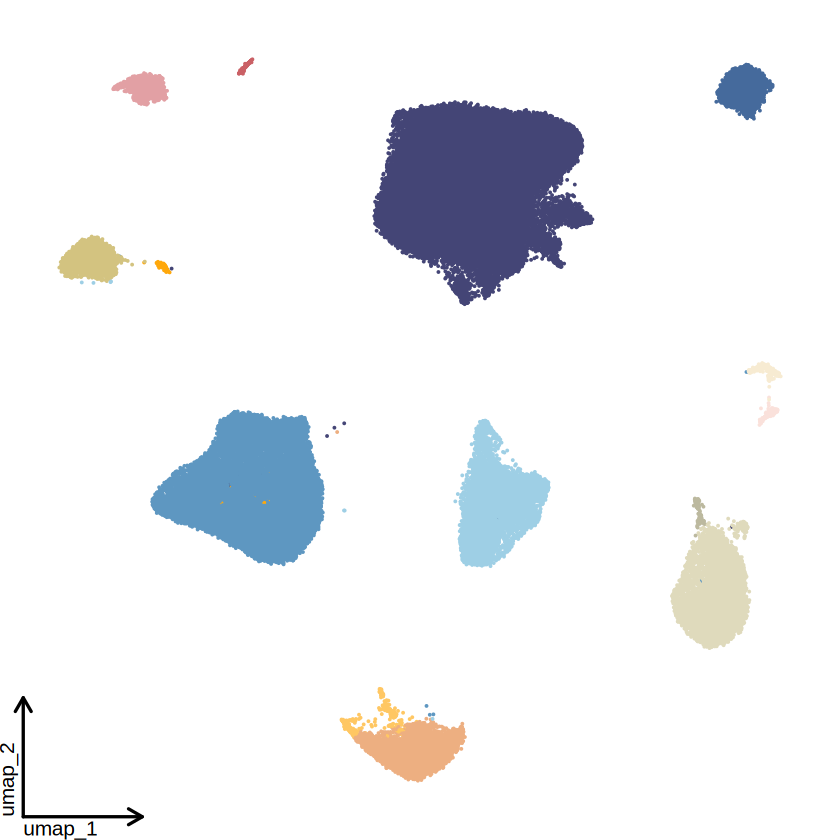

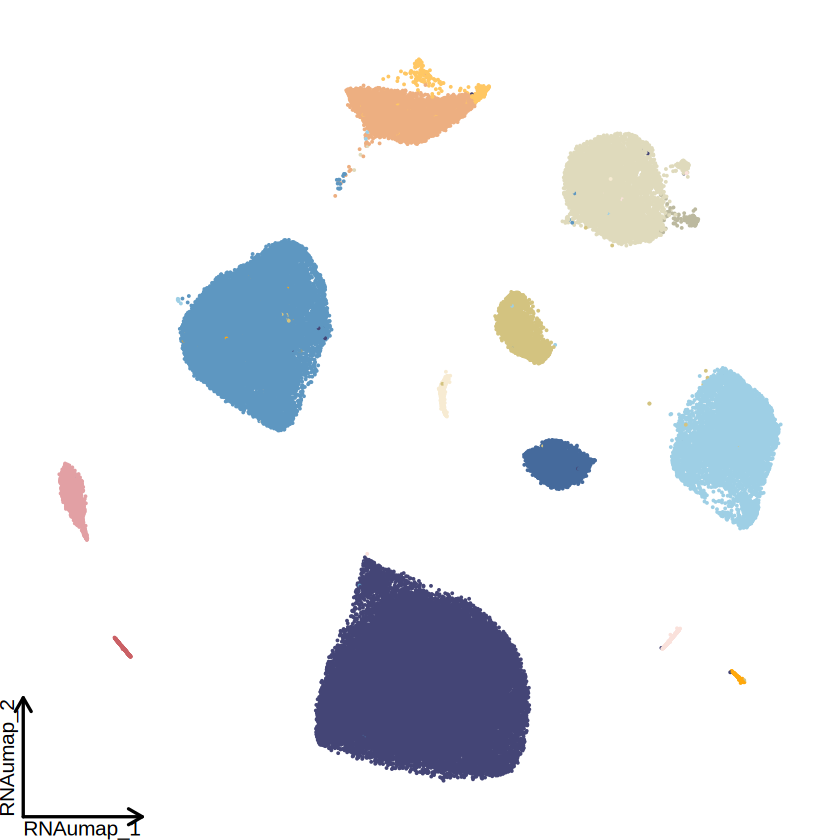

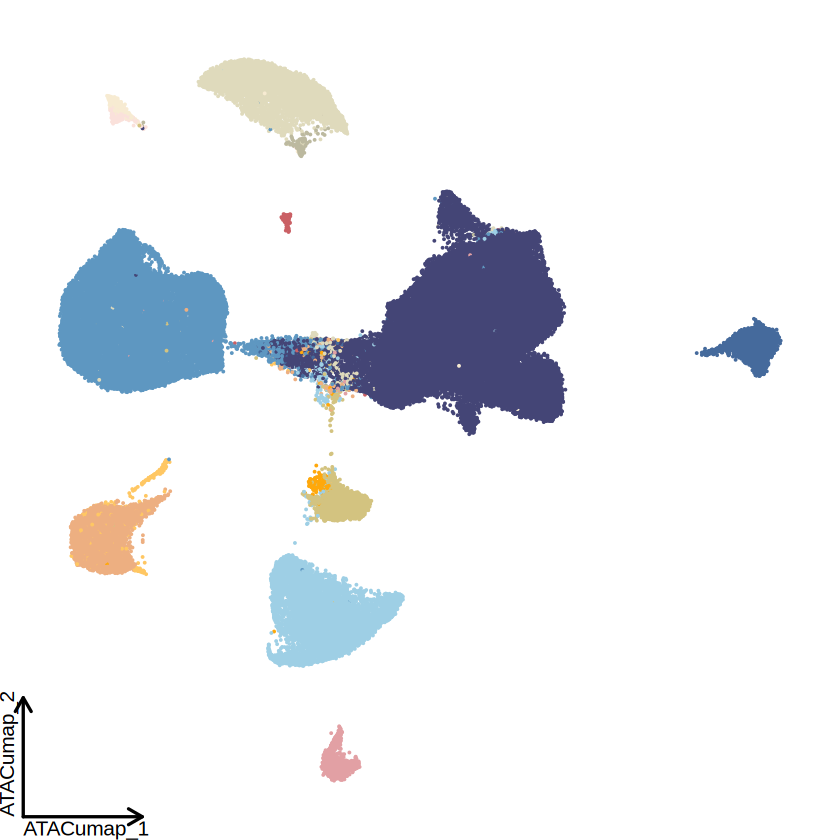

In [7]:
p1<-CellDimPlot(
 srt = mHeart,group.by = 'celltype',legend.position = 'none',label_repel = T,label_point_size = 0.1,
 reduction = "umap", label = F,label_insitu = T,theme_use = 'theme_blank',palcolor =pal(14),raster = F,
 label.fg = 'black',label.bg = 'grey95',label.bg.r = 0
)
ggsave('plot/figure1/fig1b_celltype_combine_nolabel.pdf',p1,width = 4,height = 4,create.dir = TRUE)
P2 <- CellDimPlot(
 srt = mHeart,group.by = 'celltype',legend.position = 'none',label_repel = T,label_point_size = 0.1,
 reduction = "RNA.umap", label = F,label_insitu = T,theme_use = 'theme_blank',palcolor =pal(14),raster = F,
 label.fg = 'black',label.bg = 'grey95',label.bg.r = 0
)
ggsave('plot/figure1/fig1b_celltype_RNA_nolabel.pdf',P2,width = 4,height = 4)
P3 <- CellDimPlot(
 srt = mHeart,group.by = 'celltype',legend.position = 'none',label_repel = T,label_point_size = 0.1,
 reduction = "ATAC.umap", label = F,label_insitu = T,theme_use = 'theme_blank',palcolor =pal(14),raster = F,
 label.fg = 'black',label.bg = 'grey95',label.bg.r = 0
)
ggsave('plot/figure1/fig1b_celltype_ATAC_nolabel.pdf',P3,width = 4,height = 4)
p1
P2
P3

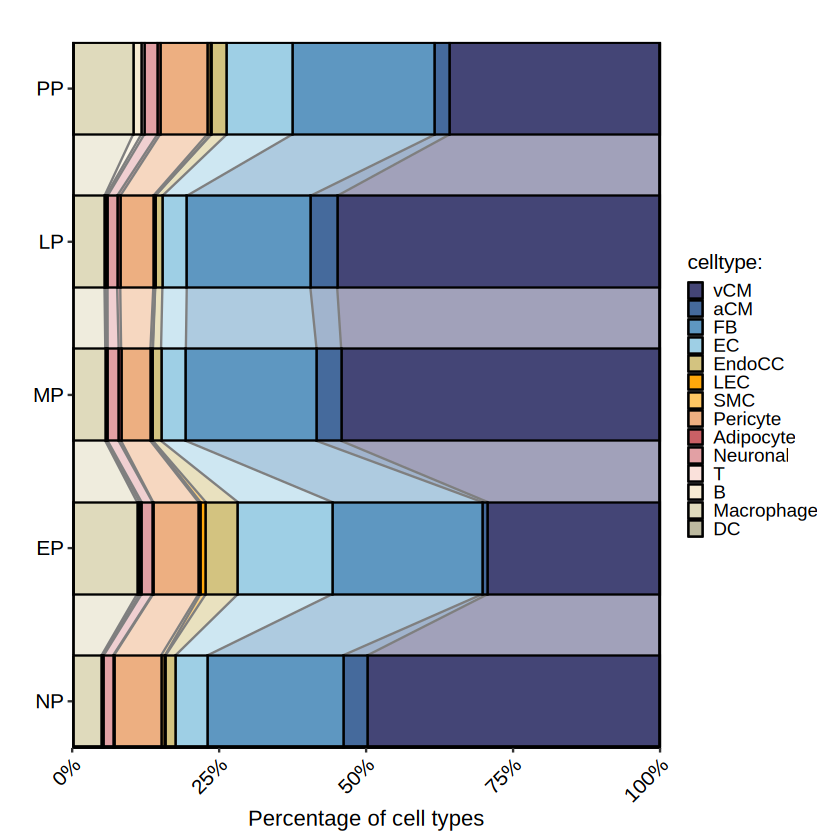

In [8]:
#fig1c cellstat
p4 <- CellStatPlot(mHeart, stat.by = "celltype", group.by = "group", label = F,palcolor = pal(14),
 flip = F,plot_type = "trend",xlab = '',ylab = 'Percentage of cell types')+coord_flip()
ggsave(plot = p4, filename = "fig1c.pdf", path = "plot/figure1/", width = 6, height = 3)
p4 

ℹ [2026-05-01 21:52:45] Data type is raw counts

ℹ [2026-05-01 21:52:45] Start differential expression test

ℹ [2026-05-01 21:52:45] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-01 21:52:57] Differential expression test completed

ℹ [2026-05-01 21:53:29] Data type is raw counts

ℹ [2026-05-01 21:53:29] Start differential expression test

ℹ [2026-05-01 21:53:29] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-01 21:53:41] Differential expression test completed

ℹ [2026-05-01 21:54:08] Data type is raw counts

ℹ [2026-05-01 21:54:08] Start differential expression test

ℹ [2026-05-01 21:54:08] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-01 21:54:18] Differential expression test completed

ℹ [2026-05-01 21:54:48] Data type is raw counts

ℹ [2026-05-01 21:54:48] Start differential expression test

ℹ [2026-05-01 21:54:48] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-01 21:54:58] Differential expression test completed

`sum

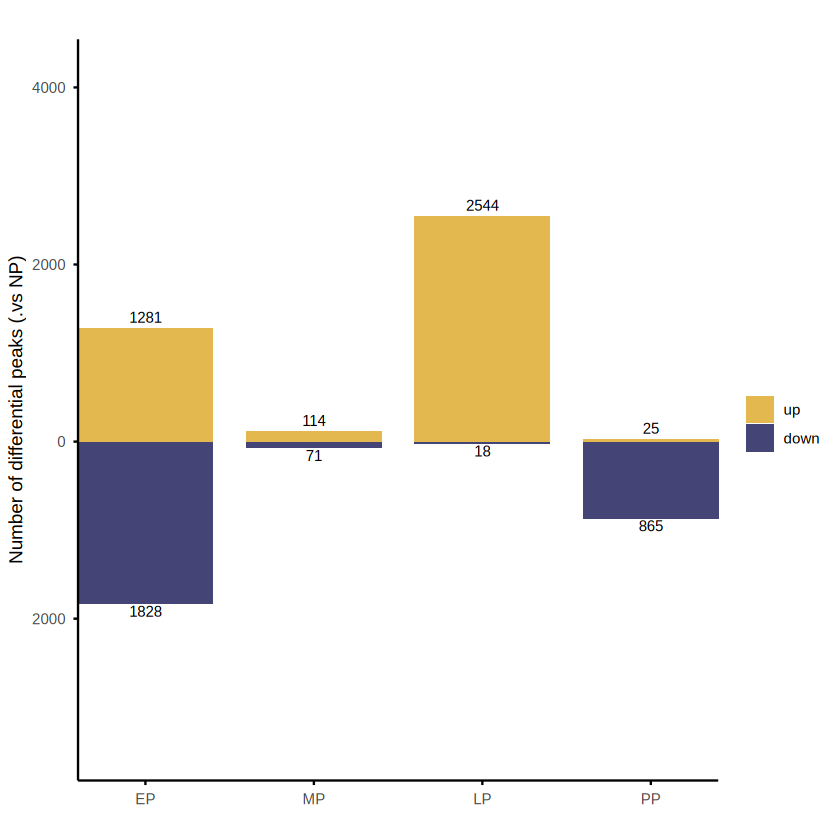

In [5]:
#fig1d
library(dplyr)
samplegroup <-c('NP','EP','MP','LP','PP')
DEGs_group <- data.frame()
 for (j in 2:5){
 mHeart<- RunDEtest(srt = mHeart, group.by = "group", assay = 'ATAC',layer = 'counts',
 fc.threshold = 1.5, only.pos = FALSE , min.pct = 0.1,cores = 30,
 group1 = samplegroup[j],group2 = 'NP')
 DEGs_group <- rbind(DEGs_group,mHeart@tools$DEtest_custom$AllMarkers_wilcox)
 }
DEGs_group$col <- ifelse(DEGs_group$avg_log2FC>0,'up','down')
DEG_dt <- DEGs_group %>%
 group_by(group1,col) %>%
 summarise(count = n())
DEG_dt$count_adjusted <- ifelse(DEG_dt$col == "down", -DEG_dt$count, DEG_dt$count)
DEG_dt$col <- factor(DEG_dt$col, levels = c("up", "down"))
p<-ggplot(DEG_dt, aes(x = group1, y = count_adjusted, fill = col)) +
 geom_bar(stat = "identity", width = 0.8) +
 scale_fill_manual(values = rev(pal(4)[1:2])) + # colorsmust match up/down match
 geom_text(aes(label = count), # show raw value (non-negative)
 vjust = ifelse(DEG_dt$col == "up", -0.5, 1.2), # adjust text position
 color = "black", size = 3) +
 labs(
 title = "",
 x = "",
 y = "Number of differential peaks (.vs NP)",
 fill=''
 ) +
 theme_minimal() +
 theme(
 legend.position = 'right',
 panel.grid.major = element_blank(),
 panel.grid.minor = element_blank(),
 axis.line = element_line(color = "black"),
 axis.ticks = element_line(color = "black"),
 axis.text.x = element_text(angle = 0, hjust = 0.5)
 ) +
 scale_x_discrete(expand = c(0, 0)) +
 scale_y_continuous(
 expand = c(0, 0),
 limits = c(min(DEG_dt$count_adjusted ) - 2000, max(DEG_dt$count) + 2000), # symmetric range
 labels = abs # yaxis labels show absolute values
 )
ggsave(plot = p, filename = "fig1d.pdf",path = "plot/figure1/", width = 3.5, height = 3)
p

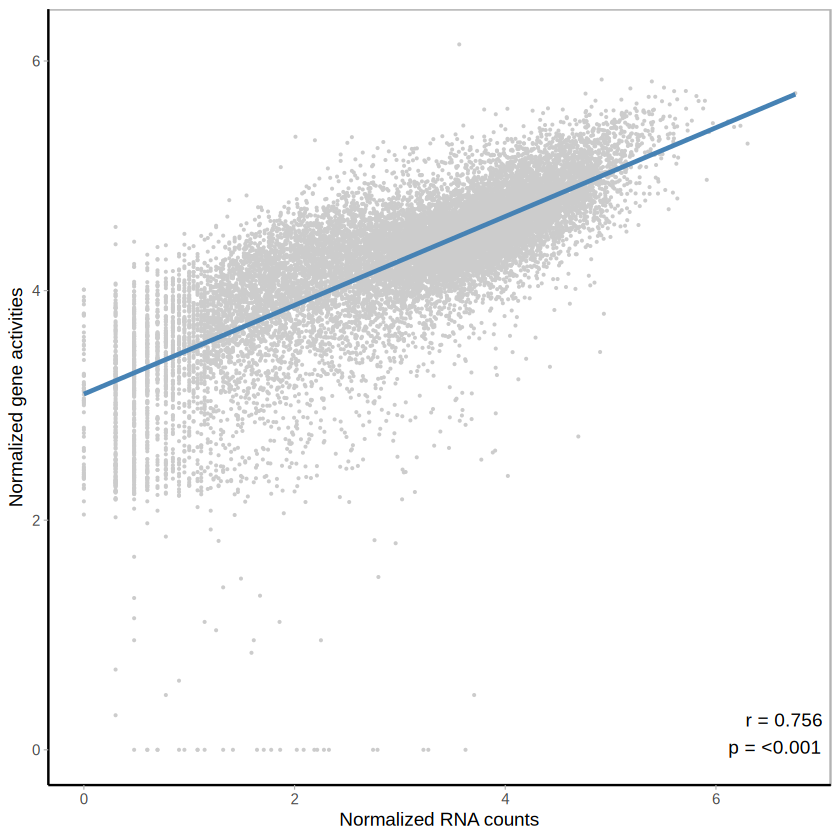

In [10]:
#fig1e
rna.dt <- AggregateExpression(mHeart, assays = 'RNA',group.by = 'celltype')[[1]]
act.dt <- AggregateExpression(mHeart, assays = 'activity',group.by = 'celltype')[[1]]
genes.dt <- intersect(row.names(rna.dt),row.names(act.dt))
p.dt <- data.frame(rna = rowSums(rna.dt[genes.dt,]),activities = rowSums(act.dt[genes.dt,]))
cor_value <- cor.test(log10(p.dt$rna + 1), log10(p.dt$activities + 1))
r <- round(cor_value$estimate, 3)
p_value <- scales::pvalue(cor_value$p.value)
p<-ggplot(data = p.dt, mapping = aes(x = log10(rna+1), y = log10(activities+1))) +
 geom_point(color='gray80', size=0.1) +
 geom_smooth(method = "lm", color = "#4682B4", formula = y ~ x) + # add linear regression line
 theme_light() +
 theme(
 panel.grid.major = element_blank(),
 panel.grid.minor = element_blank(),
 axis.line = element_line(color = "black"),
 legend.position = 'none'
 ) +
 xlab('Normalized RNA counts') + # fix axis label
 ylab('Normalized gene activities') +
 annotate("text", 
 x = Inf, y = 0, # place text in upper-right corner
 label = paste0("r = ", r, "\n", "p = ", p_value), 
 hjust = 1.1, vjust = 0.1, # fine-tune text position
 size = 4, color = "black")
ggsave(plot = p, filename = "fig1e.pdf",path = "plot/figure1/", width = 3, height = 3)
p

Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the ggseqlogo package.
  Please report the issue at <https://github.com/omarwagih/ggseqlogo/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggseqlogo package.
  Please report the issue at <https://github.com/omarwagih/ggseqlogo/issues>.”


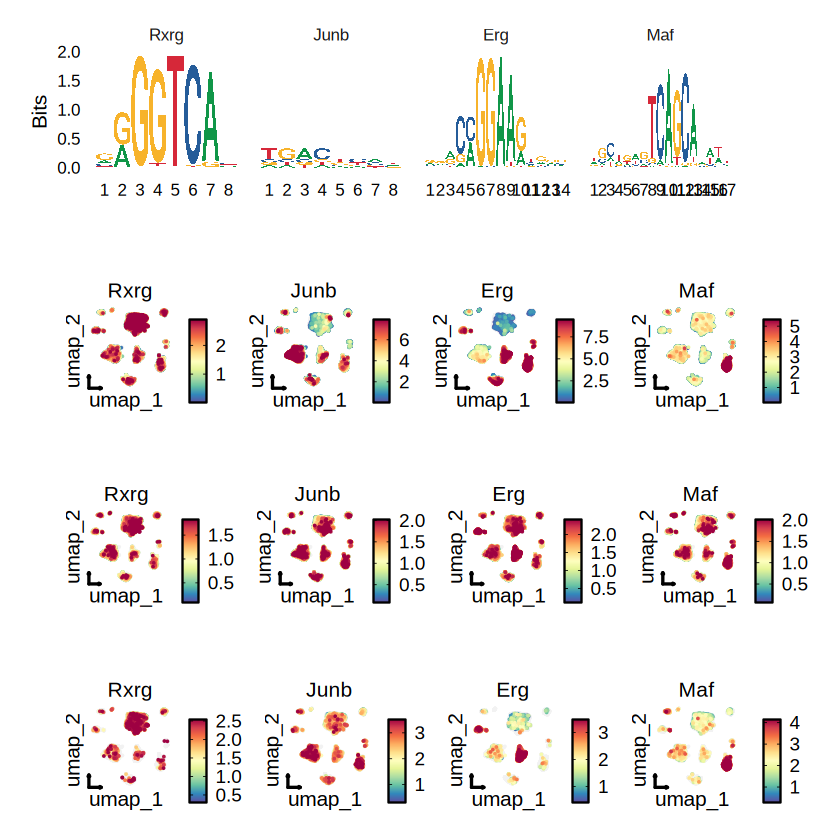

In [11]:
#fig1f
library(patchwork)
genes <- c("Rxrg", "Junb", "Erg", "Maf")
p1 <- FeatureDimPlot(
 srt = mHeart,
 features = genes,
 legend.position = "right", assay = "motif",
 bg_color = "gray95", pt.size = 0.01,
 reduction = "umap", theme_use = "theme_blank",
 raster = F, ncol = 4
)
ggsave("plot/figure1/fig1f_motif.pdf", p1,
 width = 12, height = 3, create.dir = TRUE
)
p2 <- FeatureDimPlot(
 srt = mHeart,
 features = genes,
 legend.position = "right", assay = "activity",
 bg_color = "gray95", pt.size = 0.01,
 reduction = "umap", theme_use = "theme_blank",
 raster = F, ncol = 4
)
ggsave("plot/figure1/fig1f_activity.pdf", p2,
 width = 12, height = 3, create.dir = TRUE
)
p3 <- FeatureDimPlot(
 srt = mHeart,
 features = genes,
 legend.position = "right", assay = "RNA",
 bg_color = "gray95", pt.size = 0.01,
 reduction = "umap", theme_use = "theme_blank",
 raster = F, ncol = 4
)
ggsave("plot/figure1/fig1f_RNA.pdf", p3,
 width = 12, height = 3, create.dir = TRUE
)
p4 <- MotifPlot(
 object = mHeart,
 assay = "ATAC",
 motifs = genes,
 ncol = 4
)
ggsave("plot/figure1/fig1f_motif_Bits.pdf", p4,
 width = 8, height = 2, create.dir = TRUE
)
p4 / p1 / p2 / p3

In [3]:
#fig1g
#run GO enrichment
library(clusterProfiler)
samplegroup <- c("NP", "EP", "MP", "LP", "PP")
mHeart <- RunDEtest(mHeart,
 group.by = "group", only.pos = FALSE,
 fc.threshold = 2, min.pct = 0.25
)
mHeart <- RunDEtest(
 srt = mHeart, group.by = "group",
 fc.threshold = 1, only.pos = FALSE, min.pct = 0.1,
 group1 = "NP"
)
DEGs_group <- mHeart@tools$DEtest_custom$AllMarkers_wilcox
for (j in 2:5) {
 mHeart <- RunDEtest(
 srt = mHeart, group.by = "group",
 fc.threshold = 1, only.pos = FALSE, min.pct = 0.1,
 group1 = samplegroup[j], group2 = "NP"
 )
 DEGs_group <- rbind(DEGs_group, mHeart@tools$DEtest_custom$AllMarkers_wilcox)
}
mHeart@tools$DEtest_group$AllMarkers_wilcox <- DEGs_group
allmarker <- DEGs_group %>%
 filter(p_val_adj < 0.05) %>%
 filter(pct.1 > 0.1) %>%
 filter(avg_log2FC > log2(1.5))
df_sig <- subset(allmarker)
group <- data.frame(
 gene = df_sig$gene,
 group = df_sig$group1
)
Gene_ID <- bitr(group$gene,
 fromType = "SYMBOL",
 toType = "ENTREZID",
 OrgDb = "org.Mm.eg.db"
)
data <- merge(Gene_ID, group, by.x = "SYMBOL", by.y = "gene")
levels(data$group) <- c("NP", "EP", "MP", "LP", "PP")
data_GO <- compareCluster(
 ENTREZID ~ group,
 data = data,
 fun = "enrichGO",
 OrgDb = "org.Mm.eg.db",
 ont = "BP",
 pAdjustMethod = "BH",
 pvalueCutoff = 0.05,
 qvalueCutoff = 0.05
)
res <- data_GO@compareClusterResult
for (j in 1:dim(res)) {
 arr <- unlist(strsplit(as.character(res[j, "geneID"]), split = "/"))
 gene_names <- paste(unique(data$SYMBOL[data$ENTREZID %in% arr]), collapse = "/")
 res[j, "geneID"] <- gene_names
}
writexl::write_xlsx(res, "plot/figure1/fig1g_vCM_group_GO.xlsx")



clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


ℹ [2026-05-07 22:40:02] Data type is log-normalized

ℹ [2026-05-07 22:40:02] Start differential expression test

ℹ [2026-05-07 22:40:02] Find all markers(wilcox) among [1] 5 groups...

ℹ [2026-05-07 22:40:02] Using 1 core

⠙ [2026-05-07 22:40:02] Running for NP [1/5] ■■          20% | ETA: 42s

⠹ [2026-05-07 22:40:02] Running for EP [2/5] ■■■■        40% | ETA: 32s

⠸ [2026-05-07 22:40:02] Running for MP [3/5] ■■■■■■      60% | ETA: 21s

⠼ [2026-05-07 22:40:02] Running for LP [4/5] ■■■■■■■■    80% | ETA: 10s

✔ [2026-05-07 22:40:02] Completed 5 tasks in 52.8s



ℹ [2026-05-07 2


NP EP MP LP PP 
 3  3  3  3  3 

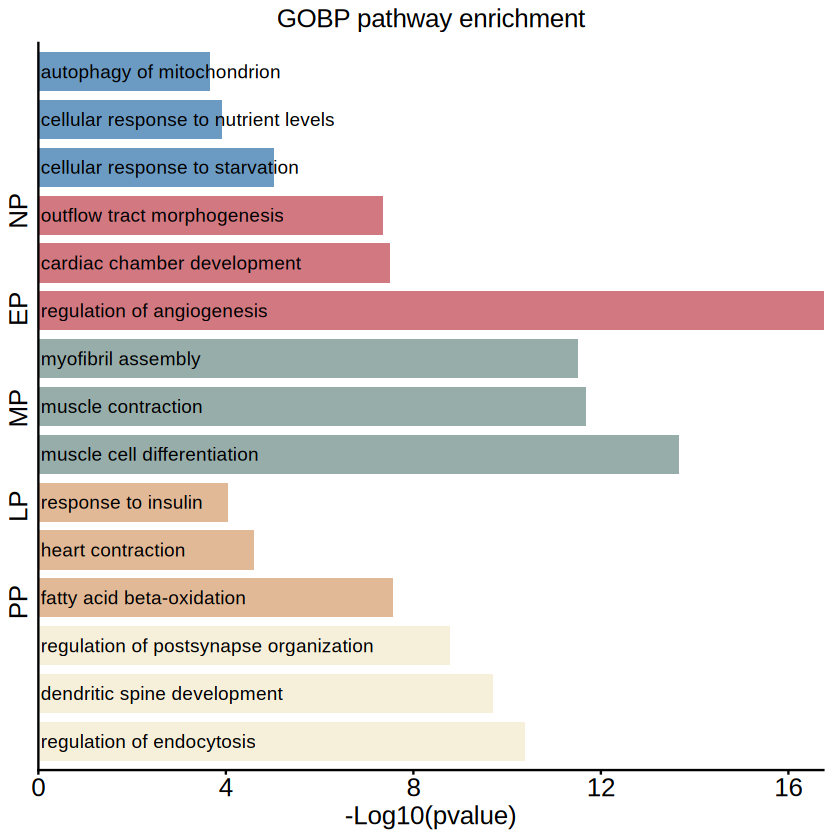

In [9]:
#Plot GOBP 
# plot
library(dplyr)
enrich <- subset(res, Description %in% c(
 "cellular response to starvation",
 "cellular response to nutrient levels",
 "autophagy of mitochondrion"
) & group %in% "NP")
enrich <- rbind(enrich, subset(res, Description %in% c(
 "regulation of angiogenesis",
 "outflow tract morphogenesis",
 "cardiac chamber development"
) & group %in% "EP"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "muscle cell differentiation",
 "myofibril assembly",
 "muscle contraction"
) & group %in% "MP"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "fatty acid beta-oxidation",
 "response to insulin",
 "heart contraction"
) & group %in% "LP"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "regulation of endocytosis",
 "dendritic spine development",
 "regulation of postsynapse organization"
) & group %in% "PP"))
colnames(enrich) <- gsub("Groups", "Cluster", colnames(enrich))
dt <- enrich
dt$order <- gsub("NP", "1", dt$Cluster)
dt$order <- gsub("EP", "2", dt$order)
dt$order <- gsub("MP", "3", dt$order)
dt$order <- gsub("LP", "4", dt$order)
dt$order <- gsub("PP", "5", dt$order)
dt <- dt[order(dt$pvalue), ]
dt <- dt %>%
 group_by(group) %>%
 arrange(desc(pvalue)) %>%
 slice_tail(n = 3)
dt <- dt[order(dt$order, decreasing = F), ]
table(dt$Cluster)
cols <- c("#4682B4", "#C65762", "#7C9895", "#DAA87C","#F4EBD0")
pal <- colorRampPalette(cols)
# plot
dt$color <- factor(c(
 rep(pal(5)[3], each = 3),
 rep(pal(5)[2], each = 3),
 rep(pal(5)[1], each = 3),
 rep(pal(5)[4], each = 3),
 rep(pal(5)[5], each = 3)
), levels = pal(5))
dt$Description <- factor(dt$Description, levels = dt$Description)
dt$geneID <- paste(substr(dt$geneID, start = 1, stop = 40), "...", sep = "")
mytheme <- theme(
 axis.title = element_text(size = 15),
 axis.text = element_text(size = 15),
 axis.text.y = element_blank(), # remove y-axis pathway labels in the custom theme:
 axis.ticks.length.y = unit(0, "cm"),
 plot.title = element_text(size = 15, hjust = 0.5),
 legend.title = element_text(size = 13), 
 legend.text = element_text(size = 11),
 plot.margin = margin(t = 5.5, r = 10, l = 5.5, b = 5.5)
)
p <- ggplot(data = dt, aes(x = -log10(pvalue), y = rev(Description), fill = Cluster)) +
 scale_fill_manual(values = pal(5)) +
 geom_bar(stat = "identity", width = 0.8, alpha = 0.8) +
 scale_x_continuous(expand = c(0, 0)) + # align bar bottoms flush with the y-axis
 labs(
 x = "-Log10(pvalue)", y = " PP LP MP EP NP ",
 title = "GOBP pathway enrichment"
 ) +
 # x = 0.61 numeric vector controlling the start position of text labels
 geom_text(size = 4, aes(x = 0.05, label = Description), hjust = 0) + # hjust = 0,left-aligned
 theme_classic() +
 mytheme +
 NoLegend()
ggsave("plot/figure1/fig1g.pdf", p , width = 5, height = 5)
p
